# Topic Extraction from YouTube Comments (NMF vs. LDA)

## 1. Imports

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from langdetect import detect, DetectorFactory
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

C:\Users\giova\nlp-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load and inspect the data

In [2]:
df = pd.read_csv("YoutubeCommentsDataSet.csv")
df.columns = df.columns.str.strip().str.lower()
print(df.shape)
print(df.isna().sum())
print("duplicates:", df.duplicated().sum())
print(df["sentiment"].value_counts())
print(df["comment"].str.split().str.len().describe())
df.sample(10, random_state=1)

(18408, 2)
comment      44
sentiment     0
dtype: int64
duplicates: 531
sentiment
positive    11432
neutral      4638
negative     2338
Name: count, dtype: int64
count    18364.000000
mean        32.932640
std         45.293523
min          1.000000
25%         12.000000
50%         21.000000
75%         38.000000
max       1353.000000
Name: comment, dtype: float64


,comment,sentiment
4485,bong cloud has one variation super easy to lea...,positive
10394,thật sự mình khuyên mono nên nghe lời khuyên c...,neutral
14310,i wish i had seen this years ago trying to vis...,positive
17290,im sure everyone would love to hear about some...,neutral
2811,never thought i would enjoy a 6 hour programmi...,positive
1544,man city playing so well so far but i feel lik...,neutral
2319,hes spot on with that maintenance number of 20...,positive
12134,this was so informative im in icse board and i...,positive
13185,what a honor to have this man in our justice h...,positive
17706,when your game turned pink after the render pi...,neutral


## 3. Remove missing values and duplicates, keep English only

In [3]:
df = df.dropna(subset=["comment"]).drop_duplicates(subset="comment")
print("after dedupe:", df.shape)

DetectorFactory.seed = 0

def detect_lang(t):
    try:
        return detect(t)
    except Exception:
        return "unk"

df["lang"] = df["comment"].apply(detect_lang)
print(df["lang"].value_counts().head(10))

df = df[df["lang"] == "en"].copy()
print(df["sentiment"].value_counts())

after dedupe: (17871, 2)
lang
en    15880
es      363
pt      360
fr      135
vi      106
id       69
tl       65
de       63
it       61
pl       57
Name: count, dtype: int64
sentiment
positive    10338
neutral      3263
negative     2279
Name: count, dtype: int64


## 4. Text cleaning

In [4]:
nltk.download("stopwords"); nltk.download("wordnet")

stop = set(stopwords.words("english")) | {
    "video", "youtube", "channel", "like", "get", "would", "one",
    "really", "also", "go", "make", "even", "much", "thing"}
lem = WordNetLemmatizer()

def clean(t):
    t = re.sub(r"http\S+|www\.\S+|&\w+;", " ", t.lower())
    t = re.sub(r"[^a-z\s]", " ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    return " ".join(lem.lemmatize(w) for w in t.split()
                    if w not in stop and len(w) > 2)

df["clean"] = df["comment"].apply(clean)
df = df[df["clean"].str.split().str.len() >= 3].reset_index(drop=True)

print(df["sentiment"].value_counts())
df[["comment", "clean"]].sample(5, random_state=2)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\giova\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\giova\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


sentiment
positive    10118
neutral      3179
negative     2254
Name: count, dtype: int64


,comment,clean
13971,one of the first films we saw as a family at t...,first film saw family drivein memory think ame...
6889,greg is so high hes on another planet,greg high he another planet
10197,sad but no judgement was he wrong hell yeah bu...,sad judgement wrong hell yeah without enablers...
8507,sting returning at wm 31 and rock returning at...,sting returning rock returning raw litrerly lo...
3199,great platform for auto crypto arbitrage but i...,great platform auto crypto arbitrage think spe...


## 5. Vectorization 1: TF-IDF

In [5]:
tfidf = TfidfVectorizer(max_df=0.5, min_df=5, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df["clean"])

density = X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])
print("TF-IDF shape:", X_tfidf.shape, "| non-zero share:", f"{density:.3%}")

TF-IDF shape: (15551, 8368) | non-zero share: 0.181%


## 6. Vectorization 2: Sentence-BERT embeddings

In [6]:
sbert = SentenceTransformer("all-MiniLM-L6-v2")
X_emb = sbert.encode(df["comment"].tolist(), batch_size=64, show_progress_bar=True)
print("Embedding shape:", X_emb.shape)

Batches: 100%|██████████| 243/243 [00:35<00:00,  6.91it/s]

Embedding shape: (15551, 384)


## 7. Comparing the two vectorizations (nearest-neighbour spot check)

In [7]:
i = df.index[df["sentiment"] == "negative"][0]
print("QUERY:", df.loc[i, "comment"][:200], "\n")

for name, X in [("TF-IDF", X_tfidf), ("SBERT", X_emb)]:
    sims = cosine_similarity(X[i:i+1], X).ravel()
    top = sims.argsort()[::-1][1:4]
    print(f"--- {name} nearest comments ---")
    for j in top:
        print(f"{sims[j]:.2f} | {df.loc[j, 'comment'][:150]}")

QUERY: here in nz 50 of retailers don’t even have contactless credit card machines like paywave which support apple pay they don’t like the high fees that come with these 

--- TF-IDF nearest comments ---
0.72 | for now i need both apple pay and the physical credit card
0.52 | apple pay is so convenient secure and easy to use i used it while at the korean and japanese airports no need for physical credit cards
0.42 | at this point i don’t think his credit card company cares anymore
--- SBERT nearest comments ---
0.71 | in the united states we have an abundance of retailers that accept apple pay but its still good to carry the physical card with you being there are st
0.67 | whenever i go to a place that doesn’t take apple pay doesn’t happen too often it’s such a drag between ‘contactless covid’ habits and my getting the a
0.67 | apple pay is so convenient secure and easy to use i used it while at the korean and japanese airports no need for physical credit cards


## 8. Negative subset with extra stop words
The dataset has no punctuation, so tokens such as "dont" slip past the standard stop-word list. A custom list removes them and other generic words.

In [8]:
extra = {w.replace("'", "") for w in stopwords.words("english")} | {
    "people", "think", "know", "dont", "time", "year", "got", "way", "still",
    "never", "actually", "want", "see", "need", "say", "tell", "look", "going",
    "said", "guy", "man", "thing", "something", "someone", "good", "bad",
    "feel", "take", "first", "work", "day", "made", "fact", "lot"}

neg = df[df["sentiment"] == "negative"].reset_index(drop=True)
print("negative comments:", len(neg))

neg["clean2"] = neg["clean"].apply(lambda t: " ".join(w for w in t.split() if w not in extra))
neg = neg[neg["clean2"].str.split().str.len() >= 3].reset_index(drop=True)
print("after extra stop words:", len(neg))

texts = [t.split() for t in neg["clean2"]]
dictionary = Dictionary(texts)

tf = TfidfVectorizer(max_df=0.3, min_df=5); Xt = tf.fit_transform(neg["clean2"])
cv = CountVectorizer(max_df=0.3, min_df=5);  Xc = cv.fit_transform(neg["clean2"])
print("vocab size:", Xt.shape[1])

negative comments: 2254
after extra stop words: 2228
vocab size: 1578


## 9. Helper functions

In [9]:
def top_words(model, names, n=10):
    return [[names[j] for j in c.argsort()[-n:][::-1]] for c in model.components_]

def report(model, X, names, label):
    W = model.transform(X)
    dom = W.argmax(1)
    dom[W.sum(1) == 0] = -1          # comments with no vocabulary words left
    print(f"\n===== {label} =====")
    for t, comp in enumerate(model.components_):
        words = [names[j] for j in comp.argsort()[-10:][::-1]]
        share = (dom == t).mean()
        rep = neg["comment"][W[:, t].argmax()][:160]
        print(f"\nTopic {t} ({share:.1%} of comments)")
        print("  words:", ", ".join(words))
        print("  e.g.:", rep)
    print(f"\nunassigned: {(dom == -1).mean():.1%}")

## 10. Choosing the number of topics (c_v coherence)

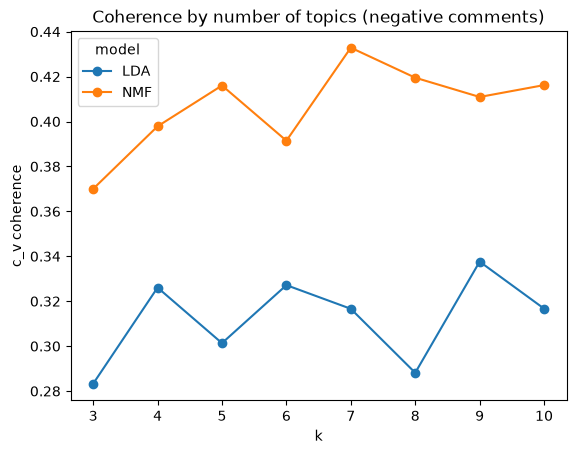

model    LDA    NMF
k                  
3      0.283  0.370
4      0.326  0.398
5      0.301  0.416
6      0.327  0.391
7      0.317  0.433
8      0.288  0.420
9      0.338  0.411
10     0.317  0.416


In [10]:
rows = []
for k in range(3, 11):
    nmf_k = NMF(n_components=k, init="nndsvd", random_state=42, max_iter=500).fit(Xt)
    lda_k = LatentDirichletAllocation(n_components=k, random_state=42, max_iter=20).fit(Xc)
    for name, m, names in [("NMF", nmf_k, tf.get_feature_names_out()),
                           ("LDA", lda_k, cv.get_feature_names_out())]:
        c = CoherenceModel(topics=top_words(m, names), texts=texts,
                           dictionary=dictionary, coherence="c_v",
                           processes=1).get_coherence()
        rows.append((name, k, c))

res = pd.DataFrame(rows, columns=["model", "k", "coherence"])
table = res.pivot(index="k", columns="model", values="coherence")
table.plot(marker="o")
plt.ylabel("c_v coherence"); plt.title("Coherence by number of topics (negative comments)")
plt.savefig("coherence.png", dpi=200, bbox_inches="tight")
plt.show()
print(table.round(3))

## 11. Final models and topic reports
NMF k=7 and LDA k=9 are each model's best k by coherence; LDA k=7 allows a comparison at the same k.

In [11]:
nmf = NMF(n_components=7, init="nndsvd", random_state=42, max_iter=500).fit(Xt)
lda9 = LatentDirichletAllocation(n_components=9, random_state=42, max_iter=20).fit(Xc)
lda7 = LatentDirichletAllocation(n_components=7, random_state=42, max_iter=20).fit(Xc)

report(nmf,  Xt, tf.get_feature_names_out(), "NMF k=7")
report(lda9, Xc, cv.get_feature_names_out(), "LDA k=9")
report(lda7, Xc, cv.get_feature_names_out(), "LDA k=7")


===== NMF k=7 =====

Topic 0 (39.0% of comments)
  words: life, could, wrong, love, show, always, ever, sad, great, everyone
  e.g.: this dude contradicts himself multiple times…sometimes within the same sentence lol but you can see the being in the kkk has wrecked his life more than anything

Topic 1 (5.9% of comments)
  words: game, play, xbox, console, new, every, drm, pas, pretty, computer
  e.g.: pretty scummy on sonys part on this one the game wars are always fair game tactics until you do practices that deliberately sabotage the competition ms doesnt n

Topic 2 (4.4% of comments)
  words: cant, help, believe, talking, stop, understand, ice, move, member, cry
  e.g.: i cant beleive how consistent agn has been for years now

Topic 3 (5.6% of comments)
  words: document, trump, classified, president, law, planted, back, believe, box, declassified
  e.g.: “just documents” classified documents in unauthorized hands and insecure property is “just documents”

Topic 4 (5.7% of comments

## 12. Figure: NMF topic shares
The labels were assigned by reading each topic's top words. If you change the data or settings, topic numbers can change, so re-check this mapping against the report above.

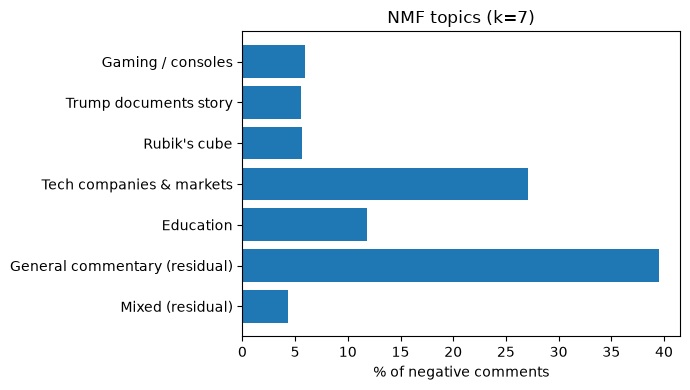

In [12]:
topic_labels = {1: "Gaming / consoles", 3: "Trump documents story", 4: "Rubik's cube",
                5: "Tech companies & markets", 6: "Education", 0: "General commentary (residual)",
                2: "Mixed (residual)"}

W = nmf.transform(Xt)
dom = W.argmax(1)
order = [1, 3, 4, 5, 6, 0, 2]
shares = [(dom == t).mean() * 100 for t in order]

plt.figure(figsize=(7, 4))
plt.barh([topic_labels[t] for t in order][::-1], shares[::-1])
plt.xlabel("% of negative comments"); plt.title("NMF topics (k=7)")
plt.tight_layout()
plt.savefig("nmf_topics.png", dpi=200)
plt.show()